# Sequence-conditioned bank diagnostics (ISI=1 non-monotonicity)

This notebook combines d' non-monotonicity checks with bank-level metrics from pure-bank simulation, but computed from generated sequences in three scenarios.

In [44]:

import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.runners_v2 import compute_score, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from utls.toy_experiments import make_compact_multi_isi_sequences
from utls.sigma_fitting import log_mid
from encoders import *
from sklearn.metrics import roc_auc_score

try:
    get_ipython()
    from tqdm.notebook import trange
except NameError:
    from tqdm import trange


In [45]:

# Setup + encoding

def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path

CONFIG_PATH = "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
model_cfg, _ = load_config(CONFIG_PATH)

exp_cfg = model_cfg["experiment"]
which_task, is_multi = exp_cfg["which_task"], exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

metric = model_cfg["metric"]
noise_cfg = model_cfg["noise_model"]
noise_mode, t_step = noise_cfg["name"], noise_cfg["t_step"]

repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
encoder_cfg = dict(
    encoder_type=encoder_type, model_name=encoder_type, task=encoder_task,
    statistics_dict=statistics_set.statistics, model_params=model_params,
    pc_dims=pc_dims, sr=20000, duration=2.0, rms_level=0.05,
    time_avg=time_avg, device="cuda",
)
if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)

param_bounds = {"sigma0": (3.0, 22), "sigma1": (0.01, 10.0), "sigma2": (0.0005, 0.5)}
sigma2_init = log_mid(*param_bounds["sigma2"])
SIGMA0 = 13.5
SIGMA1_GRID = np.exp(np.linspace(np.log(0.01), np.log(10.0), 25))

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"Encoded shape: {X.shape}; pool={len(stimulus_pool)}")


LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded shape: torch.Size([80, 186368]); pool=80


In [56]:

# Generate many randomized experiments in each scenario

def make_many_randomized_sequences(stimulus_pool, isi_values, length, n_batches, n_sequences_per_batch, min_pairs_per_isi, base_seed):
    all_exps, all_keys = [], []
    for b in range(n_batches):
        exps, keys = make_compact_multi_isi_sequences(
            stimulus_pool=stimulus_pool,
            isi_values=isi_values,
            n_sequences=n_sequences_per_batch,
            length=length,
            min_pairs_per_isi=min_pairs_per_isi,
            seed=base_seed + 997 * b,
        )
        all_exps.extend(exps)
        all_keys.extend(keys)
    return all_exps, all_keys

short_exps, short_keys = make_many_randomized_sequences(stimulus_pool, [1], 15, n_batches=10, n_sequences_per_batch=12, min_pairs_per_isi=5, base_seed=1000)
long_exps, long_keys = make_many_randomized_sequences(stimulus_pool, [1], 60, n_batches=1, n_sequences_per_batch=6, min_pairs_per_isi=5, base_seed=4000)
mixed_exps, mixed_keys = make_many_randomized_sequences(stimulus_pool, [1,2,4], 60, n_batches=1, n_sequences_per_batch=6, min_pairs_per_isi=5, base_seed=9000)

seq_configs = {
    #"ISI=[1] L=15": {"exps": short_exps, "keys": short_keys},
    "ISI=[1] L=60": {"exps": long_exps, "keys": long_keys},
    "ISI=[1,2,4] L=60": {"exps": mixed_exps, "keys": mixed_keys},
}
for name, cfg in seq_configs.items():
    print(name, len(cfg["exps"]), len(cfg["exps"][0]))


Aggregate ISI usage across all sequences:
  ISI -1: 120
  ISI 1: 60
  ISI 2: 70
  ISI 4: 110
ISI=[1] L=60 6 60
ISI=[1,2,4] L=60 6 60


In [61]:
long_exps[0]

['/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_39.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_16.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_0.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_16.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_31.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_4.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_31.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_4.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_33.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_20.wav',
 '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_33.wav',
 '

In [57]:

# Core diagnostics runner (sequence-conditioned bank stats)

def run_sequence_bank_diagnostics(experiment_list, sigma0, sigma1, seed=0):
    schedule = make_noise_schedule(noise_mode, dict(
        sigma0=sigma0, sigma1=sigma1, sigma2=sigma2_init,
        t_step=t_step, rate=0, noise_mode=noise_mode,
    ))

    dim_std = X.std(0, unbiased=True)
    rms_std = torch.sqrt(torch.mean(dim_std ** 2))
    scaled_std = dim_std / rms_std

    out = {
        "hit_scores": [], "fa_scores": [],
        "hit_by_k": defaultdict(list), "fa_by_k": defaultdict(list),
        "target_by_k": defaultdict(list), "best_non_target_by_k": defaultdict(list),
    }

    for si, seq in enumerate(experiment_list):
        torch_rng = torch.Generator(device=X.device)
        torch_rng.manual_seed(seed + si)

        seq_idx = [name_to_idx[s] for s in seq]
        bank, seen, last_seen = [], set(), {}

        for t, incoming in enumerate(seq_idx, start=1):
            probe = X[incoming].view(1, -1)
            dists, labels = [], []

            for mem in bank:
                age = t - mem["t_inserted"]
                std = schedule(age)
                noise = torch.randn(mem["mu"].shape, device=mem["mu"].device, dtype=mem["mu"].dtype, generator=torch_rng) * (std * scaled_std)
                mem["mu"] += noise
                dists.append(compute_score(probe, mem["mu"], std, metric))
                labels.append(mem["stim_idx"])

            if dists:
                k = len(bank)
                best_score = min(dists) if metric != "loglikelihood" else max(dists)
                is_repeat = incoming in seen

                if is_repeat:
                    if t - last_seen[incoming] == 1:
                        out["hit_scores"].append(best_score)
                        out["hit_by_k"][k].append(best_score)
                        target = None
                        non_targets = []
                        for d, lbl in zip(dists, labels):
                            if lbl == incoming:
                                target = d if target is None else min(target, d)
                            else:
                                non_targets.append(d)
                        if target is not None and len(non_targets) > 0:
                            out["target_by_k"][k].append(target)
                            out["best_non_target_by_k"][k].append(min(non_targets))
                else:
                    out["fa_scores"].append(best_score)
                    out["fa_by_k"][k].append(best_score)

            base = X[incoming].clone()
            enc_noise = torch.randn(base.shape, device=base.device, dtype=base.dtype, generator=torch_rng)
            mem = base + enc_noise * (sigma0 * dim_std)
            bank.append({"mu": mem.view(1, -1), "t_inserted": t, "stim_idx": incoming})
            seen.add(incoming)
            last_seen[incoming] = t

    return out


def summarize_sigma_sweep(experiment_list, sigma0, sigma1_grid, n_mc=6, seed=500_000):
    results = []
    for gi in trange(len(sigma1_grid), desc="sigma1 sweep"):
        s1 = float(sigma1_grid[gi])
        pooled = {
            "hit_scores": [], "fa_scores": [],
            "hit_by_k": defaultdict(list), "fa_by_k": defaultdict(list),
            "target_by_k": defaultdict(list), "best_non_target_by_k": defaultdict(list),
        }

        for rep in range(n_mc):
            run = run_sequence_bank_diagnostics(experiment_list, sigma0=sigma0, sigma1=s1, seed=seed + gi*100_000 + rep*10_000)
            pooled["hit_scores"].extend(run["hit_scores"])
            pooled["fa_scores"].extend(run["fa_scores"])
            for k, vals in run["hit_by_k"].items(): pooled["hit_by_k"][k].extend(vals)
            for k, vals in run["fa_by_k"].items(): pooled["fa_by_k"][k].extend(vals)
            for k, vals in run["target_by_k"].items(): pooled["target_by_k"][k].extend(vals)
            for k, vals in run["best_non_target_by_k"].items(): pooled["best_non_target_by_k"][k].extend(vals)

        hits, fas = np.array(pooled["hit_scores"]), np.array(pooled["fa_scores"])
        if len(hits) and len(fas):
            y = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
            s = np.concatenate([hits, fas])
            auroc = roc_auc_score(y, -s)
            dprime = auroc_to_dprime(auroc)
        else:
            auroc, dprime = np.nan, np.nan

        results.append({
            "sigma1": s1, "dprime": dprime, "auroc": auroc,
            "hit_mean": np.mean(hits) if len(hits) else np.nan,
            "fa_mean": np.mean(fas) if len(fas) else np.nan,
            "hit_std": np.std(hits) if len(hits) else np.nan,
            "fa_std": np.std(fas) if len(fas) else np.nan,
            "hit_by_k": {k: np.array(v) for k,v in pooled["hit_by_k"].items()},
            "fa_by_k": {k: np.array(v) for k,v in pooled["fa_by_k"].items()},
            "target_by_k": {k: np.array(v) for k,v in pooled["target_by_k"].items()},
            "best_non_target_by_k": {k: np.array(v) for k,v in pooled["best_non_target_by_k"].items()},
        })
    return results


In [58]:

N_MC = 2
sweeps = {}
for name, cfg in seq_configs.items():
    print(f"\n--- {name} ---")
    sweeps[name] = summarize_sigma_sweep(cfg["exps"], sigma0=SIGMA0, sigma1_grid=SIGMA1_GRID, n_mc=N_MC, seed=700_000)



--- ISI=[1] L=60 ---


sigma1 sweep:   0%|          | 0/25 [00:00<?, ?it/s]


--- ISI=[1,2,4] L=60 ---


sigma1 sweep:   0%|          | 0/25 [00:00<?, ?it/s]

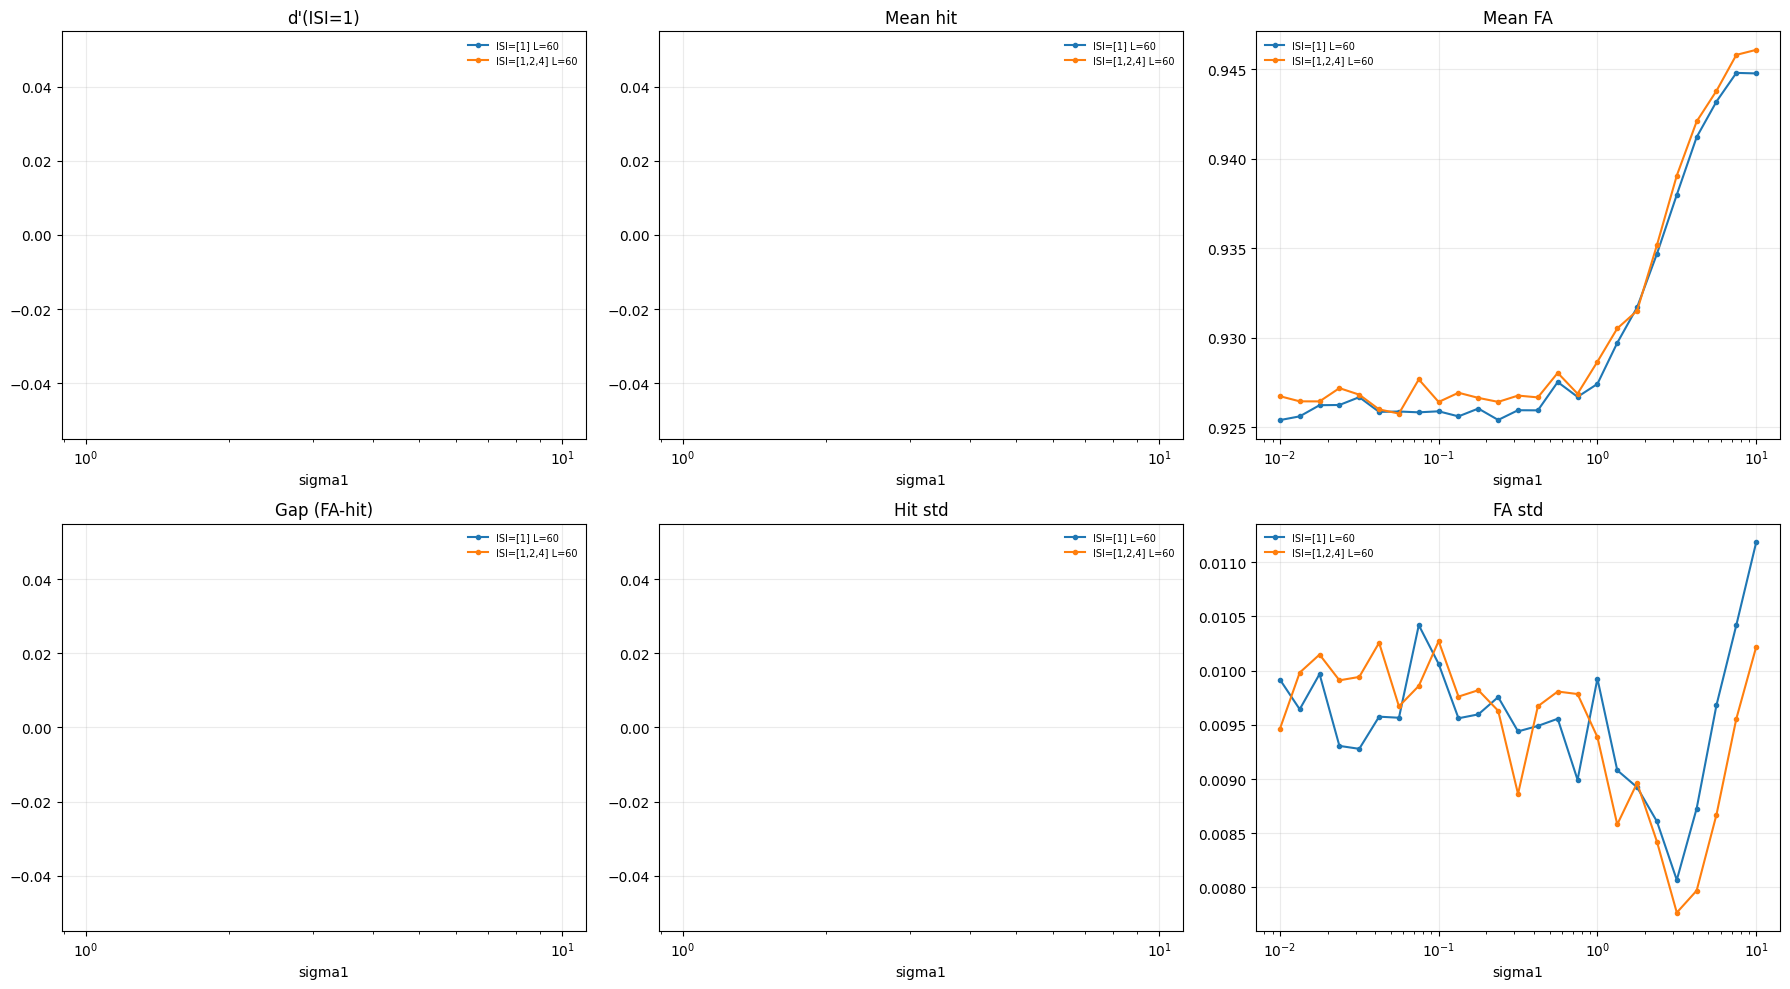

In [59]:

# Reproduce d'(ISI=1) and decomposition curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for name, results in sweeps.items():
    s1 = np.array([r["sigma1"] for r in results])
    dp = np.array([r["dprime"] for r in results])
    hm = np.array([r["hit_mean"] for r in results])
    fm = np.array([r["fa_mean"] for r in results])
    hs = np.array([r["hit_std"] for r in results])
    fs = np.array([r["fa_std"] for r in results])
    axes[0,0].plot(s1, dp, 'o-', ms=3, label=name)
    axes[0,1].plot(s1, hm, 'o-', ms=3, label=name)
    axes[0,2].plot(s1, fm, 'o-', ms=3, label=name)
    axes[1,0].plot(s1, fm-hm, 'o-', ms=3, label=name)
    axes[1,1].plot(s1, hs, 'o-', ms=3, label=name)
    axes[1,2].plot(s1, fs, 'o-', ms=3, label=name)
for ax, ttl in zip(axes.flat, ["d'(ISI=1)","Mean hit","Mean FA","Gap (FA-hit)","Hit std","FA std"]):
    ax.set_xscale('log'); ax.set_xlabel('sigma1'); ax.set_title(ttl); ax.grid(alpha=0.25); ax.legend(fontsize=7, frameon=False)
fig.tight_layout(); plt.show()


In [60]:
results

[{'sigma1': 0.010000000000000004,
  'dprime': nan,
  'auroc': nan,
  'hit_mean': nan,
  'fa_mean': 0.9267275196094161,
  'hit_std': nan,
  'fa_std': 0.009461179614324173,
  'hit_by_k': {},
  'fa_by_k': {1: array([0.94597065, 0.94596509, 0.96400813, 0.9608818 , 0.95115702,
          0.9490922 , 0.95331966, 0.93983275, 0.95882559, 0.94203605,
          0.94723261, 0.94863375]),
   2: array([0.92967932, 0.92835706, 0.93137001, 0.947066  , 0.93528529,
          0.91965909, 0.92516747, 0.93724574]),
   3: array([0.94715339, 0.9419208 , 0.94090853, 0.9505391 , 0.94573201,
          0.94170593, 0.93476516, 0.94171618, 0.94125998, 0.94834767]),
   6: array([0.93114704, 0.93967979, 0.94055209, 0.93039521, 0.93105194,
          0.93896248]),
   7: array([0.91885866, 0.92636214, 0.93384613, 0.93686916, 0.92744894,
          0.9229732 , 0.92788543, 0.92890934, 0.93286163, 0.92611109]),
   9: array([0.92237509, 0.93325166, 0.92923029, 0.93450706, 0.93360578,
          0.92370559, 0.93259645, 0.9407

In [ ]:

# Bank-size curves for low / peak / high sigma1 per scenario

def pick_sigma_indices(results):
    dp = np.array([r["dprime"] for r in results])
    return [2, int(np.nanargmax(dp)), len(results)-3]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for row, (scenario, results) in enumerate(sweeps.items()):
    for col, idx in enumerate(pick_sigma_indices(results)):
        r = results[idx]
        ks = sorted(set(r["fa_by_k"]).intersection(set(r["hit_by_k"])))
        fa_means = [np.mean(r["fa_by_k"][k]) for k in ks]
        hit_means = [np.mean(r["hit_by_k"][k]) for k in ks]
        ax = axes[row, col]
        ax.plot(ks, fa_means, 'o-', ms=3, label='FA mean')
        ax.plot(ks, hit_means, 'o-', ms=3, label='Hit mean (ISI=1)')
        ax.set_title(f"{scenario}\nsigma1={r['sigma1']:.3f}", fontsize=10)
        ax.set_xlabel('Bank size'); ax.set_ylabel('Score'); ax.grid(alpha=0.25); ax.legend(fontsize=7, frameon=False)
fig.tight_layout(); plt.show()


In [ ]:

# Local d' by bank size + target wins (long ISI=[1])
scenario = "ISI=[1] L=60"
results = sweeps[scenario]
labels = ["low", "peak", "high"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lbl, idx in zip(labels, pick_sigma_indices(results)):
    r = results[idx]
    ks = sorted(set(r["fa_by_k"]).intersection(set(r["hit_by_k"])))
    local_dp, target_win, valid_k = [], [], []
    for k in ks:
        fas, hits = np.array(r["fa_by_k"][k]), np.array(r["hit_by_k"][k])
        if len(fas) < 10 or len(hits) < 10:
            continue
        y = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
        s = np.concatenate([hits, fas])
        local_dp.append(auroc_to_dprime(roc_auc_score(y, -s)))

        tvals = np.array(r["target_by_k"].get(k, []))
        nvals = np.array(r["best_non_target_by_k"].get(k, []))
        n = min(len(tvals), len(nvals))
        target_win.append(np.mean(tvals[:n] <= nvals[:n]) if n > 0 else np.nan)
        valid_k.append(k)

    axes[0].plot(valid_k, local_dp, 'o-', ms=3, label=f"{lbl} (s1={r['sigma1']:.3f})")
    axes[1].plot(valid_k, target_win, 'o-', ms=3, label=f"{lbl} (s1={r['sigma1']:.3f})")

axes[0].set_title(f"{scenario}: local d' vs bank size"); axes[0].set_xlabel('Bank size'); axes[0].set_ylabel("d'"); axes[0].grid(alpha=0.25); axes[0].legend(fontsize=8, frameon=False)
axes[1].set_title(f"{scenario}: target win rate"); axes[1].set_xlabel('Bank size'); axes[1].set_ylabel('P(target <= best non-target)'); axes[1].axhline(0.5, ls=':', color='gray'); axes[1].set_ylim(-0.05,1.05); axes[1].grid(alpha=0.25); axes[1].legend(fontsize=8, frameon=False)
fig.tight_layout(); plt.show()


This notebook focuses on ISI=1 hits for d' and uses many re-generated randomized sequences to reduce stimulus-specific effects.